<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Copy_of_INFO_648_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score


Neural Networks are very sensitive to input scale.

• Scaling: Keeps all features on similar ranges so gradient descent works properly

• One-Hot Encoding: ANNs require numeric input, so categorical variables must be
converted
Rule:

• Numeric → Scale (MinMax or StandardScaler)

• Categorical → OneHotEncoder

# Regression vs Classification in ANN
## Regression (Continuous Output)
• Model: MLPRegressor

• Output: numeric value

## Classification (Binary or Multi-Class)

• Model: MLPClassifier

• Output: probability → class label

- **MSE** → Punishes big errors (squared)
- **RMSE** → Same idea, but interpretable units
- **MAE** → Simple average error (more forgiving)

**Mean Squared Error (MSE)**

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- Squares the errors  
- Penalizes large mistakes heavily  

**Root Mean Squared Error (RMSE)**

$$
RMSE = \sqrt{MSE}
$$

- Same units as the target variable  
- Easier to interpret than MSE  

**Mean Absolute Error (MAE)**

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

- Average absolute error  
- More robust to outliers than MSE  

In [2]:
data = pd.read_csv('/content/student_tracts_raw.csv')
new_data = data.dropna().copy() # Explicitly create a copy to avoid SettingWithCopyWarning


In [3]:
new_data.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


In [4]:
new_data2=new_data.drop(columns=['GISJOIN','STATEA','COUNTYA'])
new_data2.head()

,STATE,COUNTY,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,Alabama,Autauga County,20100,1912,693,59,536,157,118,125,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,Alabama,Autauga County,20200,2170,743,79,469,274,127,160,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,Alabama,Autauga County,20300,3373,1256,70,949,307,243,240,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,Alabama,Autauga County,20400,4386,1722,101,1357,365,234,279,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,Alabama,Autauga County,20500,10766,4082,226,2459,1623,729,937,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


In [5]:
new_data2['growth']=(new_data2['pop_total_2020']-new_data2['pop_total_2010']>0).astype(int)
new_data2.head()

,STATE,COUNTY,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,...,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type,growth
0,Alabama,Autauga County,20100,1912,693,59,536,157,118,125,...,0,1,0,13,9,1775.0,9.809944,194.904273,suburban,0
1,Alabama,Autauga County,20200,2170,743,79,469,274,127,160,...,3,0,0,24,4,2055.0,3.340505,649.602380,suburban,0
2,Alabama,Autauga County,20300,3373,1256,70,949,307,243,240,...,0,2,0,28,19,3216.0,5.349274,630.552856,suburban,0
3,Alabama,Autauga County,20400,4386,1722,101,1357,365,234,279,...,2,0,1,21,5,4246.0,6.382705,687.169468,suburban,0
4,Alabama,Autauga County,20500,10766,4082,226,2459,1623,729,937,...,19,4,4,78,22,11222.0,11.397725,944.574466,suburban,1


In [6]:
X=new_data2.drop(columns=['growth','pop_total_2020','pop_total_2010',])
y=new_data2['growth']

In [ ]:
X.isna().sum()

,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0
high_value,0


We will change mlp between MLPRegressor and MLPClassifier depending on the target variable.  We will then use the appropriate metrics to assess the model. (RMSE vs Confusion Matrix).

In [12]:

#  Load Data
#  Preprocessing (CRITICAL for Neural Nets)
# ANNs are sensitive to scale; scaling helps the weights converge faster.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor=ColumnTransformer(
  transformers=[
      ('cat',OneHotEncoder(handle_unknown='ignore'),['settlement_type','STATE', 'COUNTY'])
  ],
  remainder=MinMaxScaler()
 )

# The Model
# We'll use two hidden layers with 50 neurons each.
mlp = MLPClassifier(hidden_layer_sizes=(50, 50),
                   max_iter=100,
                   activation='relu',
                   solver='adam',
                   random_state=42,
                   verbose=True)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', mlp)
])

pipeline.fit(X_train, y_train)


Iteration 1, loss = 0.56325332
Iteration 2, loss = 0.50880886
Iteration 3, loss = 0.49063988
Iteration 4, loss = 0.47756874
Iteration 5, loss = 0.46618354
Iteration 6, loss = 0.45766437
Iteration 7, loss = 0.45007216
Iteration 8, loss = 0.44378439
Iteration 9, loss = 0.43779758
Iteration 10, loss = 0.43271949
Iteration 11, loss = 0.42849638
Iteration 12, loss = 0.42464754
Iteration 13, loss = 0.42108943
Iteration 14, loss = 0.41666708
Iteration 15, loss = 0.41330571
Iteration 16, loss = 0.40987555
Iteration 17, loss = 0.40790867
Iteration 18, loss = 0.40462879
Iteration 19, loss = 0.40197345
Iteration 20, loss = 0.39858946
Iteration 21, loss = 0.39775205
Iteration 22, loss = 0.39486878
Iteration 23, loss = 0.39223675
Iteration 24, loss = 0.38987290
Iteration 25, loss = 0.38769675
Iteration 26, loss = 0.38576966
Iteration 27, loss = 0.38393326
Iteration 28, loss = 0.38204790
Iteration 29, loss = 0.38036079
Iteration 30, loss = 0.37843622
Iteration 31, loss = 0.37710830
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder=MinMaxScaler(),
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['settlement_type', 'STATE',
                                                   'COUNTY'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=100,
                               random_state=42, verbose=True))])

In [13]:
y_pred = pipeline.predict(X_test)

In [14]:
accuracy_score(y_test,y_pred)
precision_score(y_test,y_pred)
recall_score(y_test,y_pred)

0.8408992650237787

In [15]:

# Get predictions
y_pred = pipeline.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**.5

print(f"MAE:  {mae:.2f} (Average absolute miss)")
print(f"RMSE: {rmse:.2f} (Heavily penalizes big misses)")

MAE:  0.24 (Average absolute miss)
RMSE: 0.49 (Heavily penalizes big misses)


In [16]:
#y_pred = pipeline.predict(X_test)
#print(f" Accuracy {accuracy_score(y_test,y_pred):.2f} \n Precision: {precision_score(y_test,y_pred):.2f}\n Recall {recall_score(y_test,y_pred):.2f}")

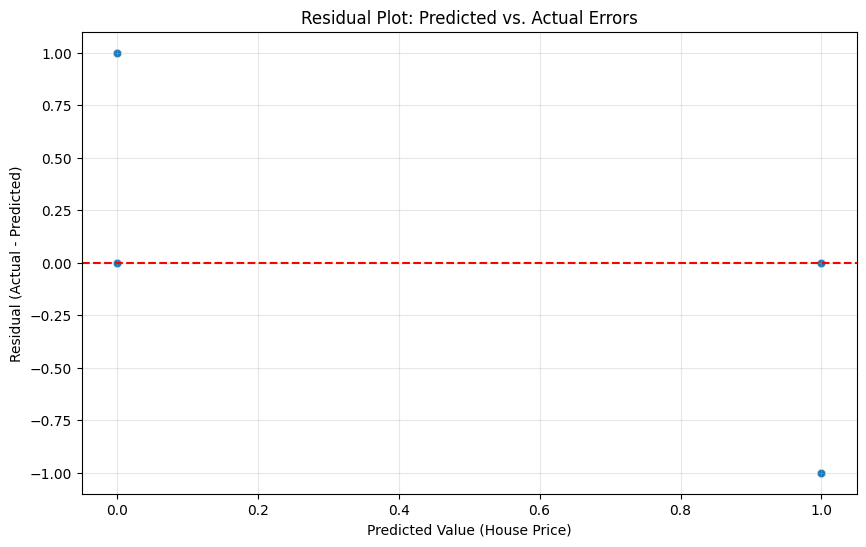

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions for the Test set (the "unseen" data)
y_pred = pipeline.predict(X_test)
residuals = y_test - y_pred

# Create the Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')  # The "Perfect Prediction" line

plt.title('Residual Plot: Predicted vs. Actual Errors')
plt.xlabel('Predicted Value (House Price)')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Assuming pred_data is meant to be a DataFrame for analysis of test data and predictions
# Create a DataFrame from X_test, y_test, and y_pred
pred_data = X_test.copy()
pred_data['actual_growth'] = y_test
pred_data['predicted_growth'] = y_pred

# Now drop rows with any missing values from this combined DataFrame
pred_data = pred_data.dropna()

In [21]:
pred_data_modified=pred=data

In [23]:
pred_data.head(20)

,STATE,COUNTY,TRACTA,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,housing_renter_occ_2010,age_under5_2010,age_5to9_2010,age_10to14_2010,...,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,land_area_sqkm,density_perkm2,settlement_type,actual_growth,predicted_growth
62952,Texas,Dallas County,14133,2030,269,152,1878,321,217,142,...,20,12,6,334,49,3.799929,1028.703431,urban,1,1
41592,New Jersey,Hudson County,11000,847,102,222,625,148,145,142,...,45,7,5,355,65,0.202987,11266.731367,urban,1,1
15905,Florida,Leon County,2411,609,55,529,80,74,89,126,...,0,1,0,4,2,46.870633,34.328531,rural,0,1
7821,California,Orange County,88107,1573,80,733,840,356,377,376,...,14,14,20,639,71,1.256844,4667.245895,urban,1,0
48689,North Carolina,Durham County,1802,2265,295,1334,931,613,589,553,...,52,33,19,1089,63,9.168341,734.702167,suburban,1,1
72445,Wisconsin,Outagamie County,12504,1247,62,851,396,198,240,218,...,0,4,0,13,7,11.332719,267.455674,suburban,1,1
5792,California,Los Angeles County,400207,1557,28,1469,88,205,289,363,...,9,29,7,193,67,5.426152,884.236195,suburban,0,0
30152,Maryland,Calvert County,860102,995,32,915,80,134,187,215,...,1,2,0,8,7,17.697686,164.032744,suburban,1,1
22889,Illinois,Kane County,853600,2290,287,1120,1170,909,829,781,...,41,46,13,3623,225,1.446675,6108.490158,urban,0,0
64247,Texas,Harris County,342800,2813,52,2693,120,665,709,845,...,3,17,12,554,89,7.445122,1189.235045,urban,1,1
